# Performance Comparison: pandas, polars, finmlkit

This notebook benchmarks 1-minute OHLCV bar generation using pandas, polars, and finmlkit on the same raw trade dataset.

Note: We intentionally exclude mlfinpy here due to incompatible NumPy version constraints between mlfinpy (<1.27) and finmlkit (~=2.2.0). Keeping this notebook separate avoids dependency resolution conflicts.


In [1]:
# Install required libraries (pin numpy to satisfy finmlkit)
!pip install "numpy~=2.2.0" pandas matplotlib polars finmlkit


  Using cached matplotlib-3.10.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached polars-1.33.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (15 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.0-cp312-cp312-macosx_10_13_universal2.whl.metadata (111 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.9 MB/s  0:00:04 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 4.5 MB/s  0:00:07 eta 0:00:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 8.6 MB/s  0:00:0

In [2]:
# Download 1 month of raw trades data from Binance
! curl -s "https://data.binance.vision/data/futures/um/monthly/trades/BTCUSDT/BTCUSDT-trades-2025-07.zip" -o "BTCUSDT-trades-2025-07.zip"
# Download the corresponding checksum
! curl -s "https://data.binance.vision/data/futures/um/monthly/trades/BTCUSDT/BTCUSDT-trades-2025-07.zip.CHECKSUM" -o "BTCUSDT-trades-2025-07.zip.CHECKSUM"
# Verify the checksum (macOS)
! shasum -a 256 -c "BTCUSDT-trades-2025-07.zip.CHECKSUM"
# Verify the checksum (Linux)
# sha256sum -c "BTCUSDT-trades-2025-07.zip.CHECKSUM"
# Unzip the downloaded file
! unzip -o "BTCUSDT-trades-2025-07.zip"
! ls


BTCUSDT-trades-2025-07.zip: OK
Archive:  BTCUSDT-trades-2025-07.zip
  inflating: BTCUSDT-trades-2025-07.csv  
BTCUSDT-trades-2025-07.csv
BTCUSDT-trades-2025-07.zip
BTCUSDT-trades-2025-07.zip.CHECKSUM
BTCUSDT.h5
featurekit_ops_quickstart.json
featurekit_talib_quickstart.json
my_fkit.json
Performance_Pandas_Polars_FinMLKit.ipynb
PerformanceTest.ipynb
QuickStartGuide.ipynb


In [3]:
# Imports
import pandas as pd
import time
import matplotlib.pyplot as plt
import polars as pl


In [4]:
# Load CSV
# (The file name in the archive is BTCUSDT-trades-2025-07.csv)
df = pd.read_csv("BTCUSDT-trades-2025-07.csv")
df.head()


,id,price,qty,quote_qty,time,is_buyer_maker
0,6440230568,107087.3,0.002,214.1746,1751328000018,True
1,6440230569,107087.3,1.391,148958.4343,1751328004439,True
2,6440230570,107087.3,3.450,369451.1850,1751328004439,True
3,6440230571,107087.3,0.046,4926.0158,1751328004439,True
4,6440230572,107087.3,0.005,535.4365,1751328004439,True


## 1. Prepare Data


In [5]:
# Common data frame with [date_time, price, volume]
base = df[["time", "price", "qty"]].copy()
base.columns = ["date_time", "price", "volume"]
base["date_time"] = pd.to_datetime(base["date_time"], unit="ms")
base.head()


,date_time,price,volume
0,2025-07-01 00:00:00.018,107087.3,0.002
1,2025-07-01 00:00:04.439,107087.3,1.391
2,2025-07-01 00:00:04.439,107087.3,3.450
3,2025-07-01 00:00:04.439,107087.3,0.046
4,2025-07-01 00:00:04.439,107087.3,0.005


## 2. finmlkit: Prepare TradesData and TimeBarKit


In [6]:
from finmlkit.bar.data_model import TradesData
from finmlkit.bar.kit import TimeBarKit

trades = TradesData(
    df.time.values,
    df.price.values,
    df.qty.values,
    id=df.id.values,
    is_buyer_maker=df.is_buyer_maker.values,
    preprocess=True,
)
print(f"TradesData processed {len(trades.data):,} records")
trades.data.head()


finmlkit.bar.data_model:416 | INFO | Inferred timestamp format: ms
finmlkit.bar.data_model:364 | INFO | Converting timestamp to nanoseconds units for processing...
finmlkit.bar.data_model:263 | WARNING | None | Found 15,593 discontinuities in trade IDs. This indicates missing trades.
finmlkit.bar.data_model:330 | INFO | Merging split trades (same timestamps) on same price level...
finmlkit.bar.data_model:191 | INFO | TradesData prepared successfully.
TradesData processed 39,171,929 records


,timestamp,price,amount,side
datetime,,,,
2025-07-01 00:00:00.018,1751328000018000000,107087.3,0.002,-1
2025-07-01 00:00:04.439,1751328004439000000,107087.3,10.909,-1
2025-07-01 00:00:04.439,1751328004439000000,107087.2,0.004,-1
2025-07-01 00:00:04.439,1751328004439000000,107087.1,0.001,-1
2025-07-01 00:00:04.439,1751328004439000000,107086.7,0.002,-1


## 3. Generate 1-minute OHLCV bars and benchmark


In [27]:
# 3.1 pandas (resample)
pandas_start = time.time()
pdf = base.set_index("date_time").sort_index()
pandas_ohlc = pdf["price"].resample("min").ohlc()
pandas_vol = pdf["volume"].resample("min").sum().rename("volume")
# trades count
pandas_trades = pdf["price"].resample("min").count().rename("trades")
pandas_vol = pandas_vol.to_frame().join(pandas_trades)
# VWAP
pandas_vwap = (pdf["price"] * pdf["volume"]).resample("min").sum() / pandas_vol["volume"]
pandas_vwap = pandas_vwap.rename("vwap")
pandas_vol = pandas_vol.join(pandas_vwap)
# median trade size
pandas_median = pdf["volume"].resample("min").median().rename("median_trade_size")
pandas_vol = pandas_vol.join(pandas_median)
# Combine OHLC and volume
pandas_1min = pandas_ohlc.join(pandas_vol).reset_index()
pandas_time = time.time() - pandas_start
print(f"\npandas execution time: {pandas_time:.4f} seconds")
print(f"Generated {len(pandas_1min):,} bars (pandas)")



pandas execution time: 7.6392 seconds
Generated 44,640 bars (pandas)


In [28]:
# 3.2 polars (group_by_dynamic)
pl_start = time.time()
pl_df = pl.from_pandas(base).sort("date_time")
polars_1min = (
    pl_df.group_by_dynamic(index_column="date_time", every="1m", period="1m", closed="left")
        .agg([
            pl.col("price").first().alias("open"),
            pl.col("price").max().alias("high"),
            pl.col("price").min().alias("low"),
            pl.col("price").last().alias("close"),
            pl.col("volume").sum().alias("volume"),
            # trades count
            pl.len().alias("trades"),
            # VWAP
            (pl.col("price") * pl.col("volume")).sum().alias("vwap"),
            # median trade size
            pl.col("volume").median().alias("median_trade_size"),
        ])
        .sort("date_time")
)
polars_time = time.time() - pl_start
print(f"\npolars execution time: {polars_time:.4f} seconds")
print(f"Generated {polars_1min.height:,} bars (polars)")



polars execution time: 0.9585 seconds
Generated 44,640 bars (polars)


In [32]:
# 3.3 finmlkit (TimeBarKit)
# First run may include JIT compilation overhead; we run twice and take the second timing.
start1 = time.time()
kit = TimeBarKit(trades, period=pd.Timedelta(minutes=1))
klines1 = kit.build_ohlcv()
first_time = time.time() - start1

start2 = time.time()
kit = TimeBarKit(trades, period=pd.Timedelta(minutes=1))
klines2 = kit.build_ohlcv()
finmlkit_time = time.time() - start2

print(f"\nfinmlkit execution time (first run, includes compile): {first_time:.4f} seconds")
print(f"finmlkit execution time (second run): {finmlkit_time:.4f} seconds")
print(f"Generated {len(klines2):,} bars (finmlkit)")


finmlkit.bar.kit:27 | INFO | Time bar builder initialized with interval: 60.0 seconds.
finmlkit.bar.base:106 | INFO | Calculating bar close tick indices and timestamps...
finmlkit.bar.base:146 | INFO | OHLCV bar calculated successfully.
finmlkit.bar.base:159 | INFO | OHLCV bar converted to DataFrame.
finmlkit.bar.kit:27 | INFO | Time bar builder initialized with interval: 60.0 seconds.
finmlkit.bar.base:106 | INFO | Calculating bar close tick indices and timestamps...
finmlkit.bar.base:146 | INFO | OHLCV bar calculated successfully.
finmlkit.bar.base:159 | INFO | OHLCV bar converted to DataFrame.

finmlkit execution time (first run, includes compile): 0.1808 seconds
finmlkit execution time (second run): 0.1440 seconds
Generated 44,640 bars (finmlkit)


## 4. Performance Comparison


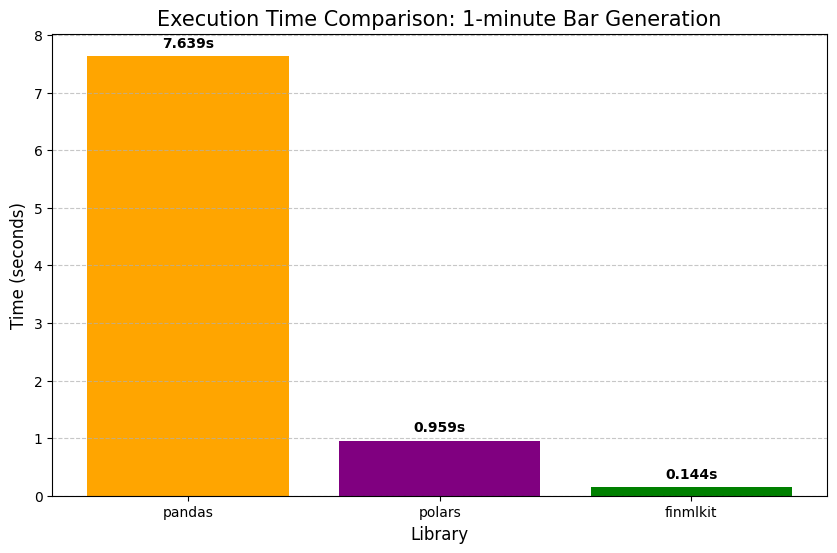

In [33]:
# Compare execution time (use finmlkit second run)
libs = ["pandas", "polars", "finmlkit"]
vals = [pandas_time, polars_time, finmlkit_time]

plt.figure(figsize=(10, 6))
plt.bar(libs, vals, color=["orange", "purple", "green"])
plt.title("Execution Time Comparison: 1-minute Bar Generation", fontsize=15)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xlabel("Library", fontsize=12)

for i, v in enumerate(vals):
    plt.text(i, v + max(vals) * 0.02, f"{v:.3f}s", ha="center", fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [34]:
print(f"{round(polars_time / finmlkit_time)}x speedup compared to polars")
print(f"{round(pandas_time / finmlkit_time)}x speedup compared to pandas")

7x speedup compared to polars
53x speedup compared to pandas
